# Eksperimen MSML - Breast Cancer Classification

Notebook ini berisi eksperimen manual sebelum proses preprocessing dikonversi menjadi script otomatis. Dataset yang digunakan adalah **Breast Cancer Wisconsin Diagnostic Dataset** dengan target klasifikasi `diagnosis`.

Tahapan yang dilakukan:

1. Import library.
2. Memuat dataset.
3. Exploratory Data Analysis (EDA).
4. Data preprocessing.
5. Menyimpan dataset hasil preprocessing.

## 1. Import Library

Library yang digunakan mencakup pandas dan numpy untuk manipulasi data, matplotlib untuk visualisasi sederhana, serta scikit-learn untuk imputasi dan standardisasi fitur.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)

## 2. Memuat Dataset

Dataset raw disimpan di folder `breast_cancer_raw`. Notebook ini berada di folder `preprocessing`, sehingga path dataset raw adalah `../breast_cancer_raw/breast_cancer_raw.csv`.

In [2]:
RAW_PATH = Path("../breast_cancer_raw/breast_cancer_raw.csv")
OUTPUT_DIR = Path("breast_cancer_preprocessing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

raw_data = pd.read_csv(RAW_PATH)
raw_data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Shape dataset:", raw_data.shape)
raw_data.info()

Shape dataset: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_radius              569 non-null    float64
 1   mean_texture             569 non-null    float64
 2   mean_perimeter           569 non-null    float64
 3   mean_area                569 non-null    float64
 4   mean_smoothness          569 non-null    float64
 5   mean_compactness         569 non-null    float64
 6   mean_concavity           569 non-null    float64
 7   mean_concave_points      569 non-null    float64
 8   mean_symmetry            569 non-null    float64
 9   mean_fractal_dimension   569 non-null    float64
 10  radius_error             569 non-null    float64
 11  texture_error            569 non-null    float64
 12  perimeter_error          569 non-null    float64
 13  area_error               569 non-null    float64
 14  s

## 3. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami ukuran dataset, tipe data, missing value, duplikasi, distribusi target, statistik deskriptif, dan korelasi awal antarfitur.

In [4]:
# Mengecek missing value setiap kolom
missing_values = raw_data.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
# Mengecek data duplikat
print("Jumlah data duplikat:", raw_data.duplicated().sum())

Jumlah data duplikat: 0


In [6]:
# Statistik deskriptif
raw_data.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean_texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean_area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean_compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean_concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [7]:
# Distribusi target
raw_data["diagnosis"].value_counts().sort_index()

diagnosis
0    212
1    357
Name: count, dtype: int64

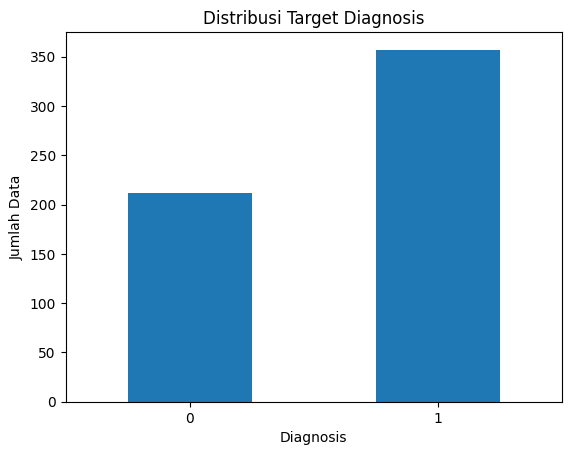

In [8]:
# Visualisasi distribusi target
raw_data["diagnosis"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Target Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Korelasi fitur terhadap target diagnosis
correlation_to_target = raw_data.corr(numeric_only=True)["diagnosis"].sort_values(key=abs, ascending=False)
correlation_to_target.head(10)

diagnosis               1.000000
worst_concave_points   -0.793566
worst_perimeter        -0.782914
mean_concave_points    -0.776614
worst_radius           -0.776454
mean_perimeter         -0.742636
worst_area             -0.733825
mean_radius            -0.730029
mean_area              -0.708984
mean_concavity         -0.696360
Name: diagnosis, dtype: float64

## 4. Data Preprocessing

Tahapan preprocessing yang digunakan:

1. Menghapus kolom yang seluruh nilainya kosong.
2. Menghapus data duplikat.
3. Menghapus baris dengan target kosong.
4. Memisahkan fitur dan target.
5. Menangani missing value fitur numerik menggunakan median.
6. Menangani outlier dengan metode IQR clipping.
7. Melakukan standardisasi fitur numerik menggunakan `StandardScaler`.
8. Menyimpan dataset hasil preprocessing.

In [10]:
TARGET_COLUMN = "diagnosis"

def clean_data(df: pd.DataFrame, target_column: str = TARGET_COLUMN) -> pd.DataFrame:
    data = df.copy()
    data = data.dropna(axis=1, how="all")
    data = data.drop_duplicates().reset_index(drop=True)
    data = data.dropna(subset=[target_column]).reset_index(drop=True)
    return data

cleaned_data = clean_data(raw_data)
print("Shape sebelum cleaning:", raw_data.shape)
print("Shape setelah cleaning:", cleaned_data.shape)

Shape sebelum cleaning: (569, 31)
Shape setelah cleaning: (569, 31)


In [11]:
feature_columns = [column for column in cleaned_data.columns if column != TARGET_COLUMN]
numeric_columns = cleaned_data[feature_columns].select_dtypes(include=[np.number]).columns.tolist()

X = cleaned_data[numeric_columns].copy()
y = cleaned_data[TARGET_COLUMN].astype(int).copy()

print("Jumlah fitur numerik:", len(numeric_columns))
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Jumlah fitur numerik: 30
Shape X: (569, 30)
Shape y: (569,)


In [12]:
# Imputasi missing value numerik menggunakan median
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=numeric_columns)

print("Jumlah missing value setelah imputasi:", X_imputed.isnull().sum().sum())

Jumlah missing value setelah imputasi: 0


In [13]:
def cap_outliers_iqr(df: pd.DataFrame, numeric_columns: list[str]) -> pd.DataFrame:
    data = df.copy()
    for column in numeric_columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

X_capped = cap_outliers_iqr(X_imputed, numeric_columns)
X_capped.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,0.07871,0.84865,0.9053,5.9835,86.20,0.006399,0.049040,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,0.05667,0.54350,0.7339,3.3980,74.08,0.005225,0.013080,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,0.05999,0.74560,0.7869,4.5850,86.20,0.006150,0.040060,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758
3,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,0.07875,0.49560,1.1560,3.4450,27.23,0.009110,0.061505,0.05661,0.01867,0.03596,0.008023,14.91,26.50,98.87,567.70,0.1901,0.62695,0.6869,0.2575,0.41915,0.12301
4,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,0.05883,0.75720,0.7813,5.4380,86.20,0.011490,0.024610,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.00,0.1374,0.20500,0.4000,0.1625,0.23640,0.07678


In [14]:
# Standardisasi fitur numerik
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_capped), columns=numeric_columns)

processed_data = X_scaled.copy()
processed_data[TARGET_COLUMN] = y.values

processed_data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis
0,1.176800,-2.121200,1.357375,1.184085,1.618861,2.541404,2.647422,2.620973,2.348535,2.511708,2.280613,-0.603532,2.343091,2.110995,-0.197982,1.639184,1.152362,0.778698,1.520305,1.462719,2.006477,-1.375159,2.439568,2.287627,1.344848,2.641905,2.246192,2.296076,2.443918,2.225247,0
1,1.949929,-0.354875,1.795991,2.249396,-0.842995,-0.498189,-0.000497,0.574944,0.017882,-0.925449,0.780609,-0.956881,0.498609,1.611678,-0.685568,-0.768782,-0.556348,0.328106,-0.937631,-0.033315,1.921384,-0.370048,1.631542,2.287627,-0.377098,-0.443388,-0.137634,1.087084,-0.234408,0.355314,0
2,1.686226,0.476899,1.670052,1.846217,0.975239,1.148680,1.496076,2.110330,1.004666,-0.407692,1.774057,-0.847619,1.345409,2.110995,-0.301397,1.037862,0.402825,1.637925,0.373573,0.550819,1.611558,-0.019582,1.434234,1.807751,0.546654,1.223448,0.920718,1.955000,1.369057,0.265197,0
3,-0.791983,0.268955,-0.606410,-0.831485,2.737521,2.541404,2.091997,1.506601,2.521318,2.517947,0.545151,-0.086703,0.532139,-0.318438,0.927950,2.473870,1.292444,1.289491,2.423376,2.491558,-0.277945,0.140773,-0.245395,-0.593838,2.595949,2.641905,2.119474,2.175786,2.443918,2.482456,0
4,1.866023,-1.174698,1.891531,2.154338,0.295047,0.599453,1.504202,1.482665,0.006363,-0.588595,1.831079,-0.859164,1.953934,2.110995,1.916411,0.003294,1.305576,1.322328,-0.378732,0.856659,1.386825,-1.484267,1.424838,1.525780,0.232758,-0.314469,0.665254,0.729259,-0.951602,-0.410683,0


In [15]:
# Menyimpan dataset hasil preprocessing
OUTPUT_PATH = OUTPUT_DIR / "breast_cancer_preprocessed.csv"
processed_data.to_csv(OUTPUT_PATH, index=False)

print("Dataset hasil preprocessing disimpan di:", OUTPUT_PATH)
print("Shape dataset hasil preprocessing:", processed_data.shape)

Dataset hasil preprocessing disimpan di: breast_cancer_preprocessing/breast_cancer_preprocessed.csv
Shape dataset hasil preprocessing: (569, 31)


In [16]:
# Validasi akhir dataset hasil preprocessing
print("Missing value akhir:", processed_data.isnull().sum().sum())
print("Duplikasi akhir:", processed_data.duplicated().sum())
processed_data.describe().T.head(10)

Missing value akhir: 0
Duplikasi akhir: 0


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,2.622390e-16,1.00088,-2.122184,-0.708077,-0.207641,0.514546,2.348480
mean_texture,569.0,3.434082e-16,1.00088,-2.281340,-0.737300,-0.099128,0.608357,2.626843
mean_perimeter,569.0,-3.996022e-16,1.00088,-2.073821,-0.711070,-0.230330,0.545283,2.429814
mean_area,569.0,7.492542e-17,1.00088,-1.626699,-0.719381,-0.290634,0.468523,2.250380
mean_smoothness,569.0,1.748260e-16,1.00088,-2.800558,-0.723778,-0.028959,0.660741,2.737521
mean_compactness,569.0,-1.248757e-17,1.00088,-1.699191,-0.776247,-0.214658,0.550814,2.541404
mean_concavity,569.0,9.990056e-17,1.00088,-1.177440,-0.777090,-0.343964,0.592715,2.647422
mean_concave_points,569.0,0.000000e+00,1.00088,-1.291295,-0.751131,-0.400330,0.676807,2.818714
mean_symmetry,569.0,-4.995028e-17,1.00088,-2.669855,-0.723165,-0.058910,0.574628,2.521318
mean_fractal_dimension,569.0,1.957427e-15,1.00088,-1.971880,-0.764820,-0.165968,0.548287,2.517947


## 5. Kesimpulan Eksperimen

Dataset berhasil dimuat, dianalisis, dan diproses. Tahapan preprocessing manual di notebook ini kemudian dikonversi ke file otomatisasi `automate_Feomita_Ramadhany_Fudiansah.py`, sehingga preprocessing dapat dijalankan ulang secara konsisten melalui terminal maupun GitHub Actions.